In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Sahil Sharma\Downloads\archive (1)\cumulative.csv")

In [3]:
df.tail()
# 1)KOI -- here the koi represents the kepler objects of interest
# 2)KEPID -- means kepler intput catalog ID 
        #    what it tells you , the unique id number assigned to the host star before the mission even launched. every pot. planet orbiting this same star will share this exact id.
# 3)KEPOI_NAME -- kepler object of interest name 
  #           what it tells, the temporary tracking name given to a potential planet. the format is k followed by teh stars number, then a decimal.01,.02, etc., indicating the order in which the pot. planets around that star were detected.
# 4)KEPLER_NAME -- official planet name , the official name given only if the planet passes regorous vetting and is formally confirmed. if the row represents a false alarm, this columnwill just be blank(NaN).

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9561,9562,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9563,9564,10156110,K07989.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,1,...,-225.0,4.385,0.054,-0.216,1.193,0.410,-0.137,297.00977,47.121021,14.826


In [4]:
df.shape

(9564, 50)

In [5]:
duplicates = df[df.duplicated()]
duplicates

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag


In [6]:
# duplicates_by_name = df[df.duplicated(subset=[''])]
# print("Duplicates Based on Name:")
# print(duplicates_by_name)

In [7]:
df_dup = df[df.duplicated()]
df_dup 

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag


In [8]:
df.isnull().sum()

rowid                   0
kepid                   0
kepoi_name              0
kepler_name          7270
koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff   

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

In [10]:
# first of all we only keep the rows where the disposition is either confirmed or false positive.
# keep only rows that are 'NOT CANDIDATE'
df = df[df['koi_disposition'] != 'CANDIDATE']
df

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9556,9557,8258160,K03870.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-185.0,4.477,0.099,-0.121,0.857,0.138,-0.101,299.21881,44.181862,16.375
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [11]:
df.tail()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
9556,9557,8258160,K03870.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-185.0,4.477,0.099,-0.121,0.857,0.138,-0.101,299.21881,44.181862,16.375
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9563,9564,10156110,K07989.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,1,...,-225.0,4.385,0.054,-0.216,1.193,0.410,-0.137,297.00977,47.121021,14.826


In [12]:
# step 2 drop the columns that will trick your model, in pandas, df.drop() is your best friend. we will pass it a list of column names to get rid of the text id's, the automated pipeline score, and those cheat-code false positive flags. 
# list out every column that causes data leakage or contains non-numeric text strings
cols_to_remove = [
    'kepid', 'kepoi_name','kepler_name','koi_pdisposition','koi_score','koi_fpflag_nt','koi_fpflag_ss', 'koi_fpflag_ec'
]
# drop them all at once along the columns axis (axis = 1)
df = df.drop(columns=cols_to_remove)

In [13]:
df

,rowid,koi_disposition,koi_fpflag_co,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,CONFIRMED,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,CONFIRMED,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,FALSE POSITIVE,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,FALSE POSITIVE,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,CONFIRMED,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9556,9557,FALSE POSITIVE,0,23.627035,2.264000e-04,-2.264000e-04,150.036200,0.010900,-0.010900,1.096,...,-185.0,4.477,0.099,-0.121,0.857,0.138,-0.101,299.21881,44.181862,16.375
9559,9560,FALSE POSITIVE,0,8.589871,1.846000e-04,-1.846000e-04,132.016100,0.015700,-0.015700,0.765,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,FALSE POSITIVE,1,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,-0.000170,1.252,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9562,9563,FALSE POSITIVE,1,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,-0.002850,0.147,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [14]:
# step 3 clean out the NaN (MISSING) values
# kepler has a few columns that are entirely blank, and some rows that are partially blank. we handle this using dropna(). 
# frist, lets drop any columns that are entirely empty or mostly useless due to missing values. 
# drop columns if they have too many missing values (like the temp.error columns)
df = df.drop(columns=['koi_teq_err1', 'koi_teq_err2'])

In [15]:
df

,rowid,koi_disposition,koi_fpflag_co,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,CONFIRMED,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,CONFIRMED,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,FALSE POSITIVE,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,FALSE POSITIVE,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,CONFIRMED,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9556,9557,FALSE POSITIVE,0,23.627035,2.264000e-04,-2.264000e-04,150.036200,0.010900,-0.010900,1.096,...,-185.0,4.477,0.099,-0.121,0.857,0.138,-0.101,299.21881,44.181862,16.375
9559,9560,FALSE POSITIVE,0,8.589871,1.846000e-04,-1.846000e-04,132.016100,0.015700,-0.015700,0.765,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,FALSE POSITIVE,1,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,-0.000170,1.252,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9562,9563,FALSE POSITIVE,1,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,-0.002850,0.147,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7316 entries, 0 to 9563
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              7316 non-null   int64  
 1   koi_disposition    7316 non-null   object 
 2   koi_fpflag_co      7316 non-null   int64  
 3   koi_period         7316 non-null   float64
 4   koi_period_err1    6939 non-null   float64
 5   koi_period_err2    6939 non-null   float64
 6   koi_time0bk        7316 non-null   float64
 7   koi_time0bk_err1   6939 non-null   float64
 8   koi_time0bk_err2   6939 non-null   float64
 9   koi_impact         7016 non-null   float64
 10  koi_impact_err1    6939 non-null   float64
 11  koi_impact_err2    6939 non-null   float64
 12  koi_duration       7316 non-null   float64
 13  koi_duration_err1  6939 non-null   float64
 14  koi_duration_err2  6939 non-null   float64
 15  koi_depth          7016 non-null   float64
 16  koi_depth_err1     6939 non-n

In [17]:
# next, drop the individual rows that are still missing data:
# drop any row that still contains a NaN value in any column
df = df.dropna()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6630 entries, 0 to 9563
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              6630 non-null   int64  
 1   koi_disposition    6630 non-null   object 
 2   koi_fpflag_co      6630 non-null   int64  
 3   koi_period         6630 non-null   float64
 4   koi_period_err1    6630 non-null   float64
 5   koi_period_err2    6630 non-null   float64
 6   koi_time0bk        6630 non-null   float64
 7   koi_time0bk_err1   6630 non-null   float64
 8   koi_time0bk_err2   6630 non-null   float64
 9   koi_impact         6630 non-null   float64
 10  koi_impact_err1    6630 non-null   float64
 11  koi_impact_err2    6630 non-null   float64
 12  koi_duration       6630 non-null   float64
 13  koi_duration_err1  6630 non-null   float64
 14  koi_duration_err2  6630 non-null   float64
 15  koi_depth          6630 non-null   float64
 16  koi_depth_err1     6630 non-n

In [19]:
# STEP 4 : convert your target text into numbers 
# right now, your target column (koi_disposition) contains the text strings "CONFIRMED"N and "FALSE POSITIVE". machine learning algo. only understand numbers. we can use .map() to swap them out instantly.
# convert text to binary numbers: CONFIRMED becomes 1, FALSE POSITIVE becomes 0
df.loc[:, 'koi_disposition'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

In [20]:
df

,rowid,koi_disposition,koi_fpflag_co,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,1,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,1,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,1,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9556,9557,0,0,23.627035,2.264000e-04,-2.264000e-04,150.036200,0.010900,-0.010900,1.096,...,-185.0,4.477,0.099,-0.121,0.857,0.138,-0.101,299.21881,44.181862,16.375
9559,9560,0,0,8.589871,1.846000e-04,-1.846000e-04,132.016100,0.015700,-0.015700,0.765,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,0,1,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,-0.000170,1.252,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9562,9563,0,1,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,-0.002850,0.147,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [21]:
# verify your work
# once you have run those lines,you can check your clean dataframe using two simple pandas commands:
# 1)look at the first 5 rows to ensure its all numeric 
print(df.head())


   rowid koi_disposition  koi_fpflag_co  koi_period  koi_period_err1  \
0      1               1              0    9.488036     2.775000e-05   
1      2               1              0   54.418383     2.479000e-04   
2      3               0              0   19.899140     1.494000e-05   
3      4               0              0    1.736952     2.630000e-07   
4      5               1              0    2.525592     3.761000e-06   

   koi_period_err2  koi_time0bk  koi_time0bk_err1  koi_time0bk_err2  \
0    -2.775000e-05   170.538750          0.002160         -0.002160   
1    -2.479000e-04   162.513840          0.003520         -0.003520   
2    -1.494000e-05   175.850252          0.000581         -0.000581   
3    -2.630000e-07   170.307565          0.000115         -0.000115   
4    -3.761000e-06   171.595550          0.001130         -0.001130   

   koi_impact  ...  koi_steff_err2  koi_slogg  koi_slogg_err1  koi_slogg_err2  \
0       0.146  ...           -81.0      4.467           0.0

In [22]:
# verify that there are absolutely zero missing values left 
print(df.isnull().sum().sum()) # should print = 0

0


In [23]:
df

,rowid,koi_disposition,koi_fpflag_co,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,1,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,1,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,1,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9556,9557,0,0,23.627035,2.264000e-04,-2.264000e-04,150.036200,0.010900,-0.010900,1.096,...,-185.0,4.477,0.099,-0.121,0.857,0.138,-0.101,299.21881,44.181862,16.375
9559,9560,0,0,8.589871,1.846000e-04,-1.846000e-04,132.016100,0.015700,-0.015700,0.765,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,0,1,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,-0.000170,1.252,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9562,9563,0,1,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,-0.002850,0.147,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6630 entries, 0 to 9563
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              6630 non-null   int64  
 1   koi_disposition    6630 non-null   object 
 2   koi_fpflag_co      6630 non-null   int64  
 3   koi_period         6630 non-null   float64
 4   koi_period_err1    6630 non-null   float64
 5   koi_period_err2    6630 non-null   float64
 6   koi_time0bk        6630 non-null   float64
 7   koi_time0bk_err1   6630 non-null   float64
 8   koi_time0bk_err2   6630 non-null   float64
 9   koi_impact         6630 non-null   float64
 10  koi_impact_err1    6630 non-null   float64
 11  koi_impact_err2    6630 non-null   float64
 12  koi_duration       6630 non-null   float64
 13  koi_duration_err1  6630 non-null   float64
 14  koi_duration_err2  6630 non-null   float64
 15  koi_depth          6630 non-null   float64
 16  koi_depth_err1     6630 non-n

In [25]:
# import matplotlib.pyplot as plt
# # let's assume your dataframe is called 'df_clean'
# # replace 'time_column' and 'bright_column' with your actual column names

# plt.figure(figsize=(12, 6))
# plt.plot(df['time_column'], df['brightness_column'], color='blue', marker='o', linestyle='-', markersize=2)
# plt.title('Star Brightness Over Time (Light Curve)')
# plt.xlabel('Time')
# plt.ylabel('Flux (Brightness)')
# plt.grid(True)
# plt.show()

In [26]:
print(df.columns.tolist())

['rowid', 'koi_disposition', 'koi_fpflag_co', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag']


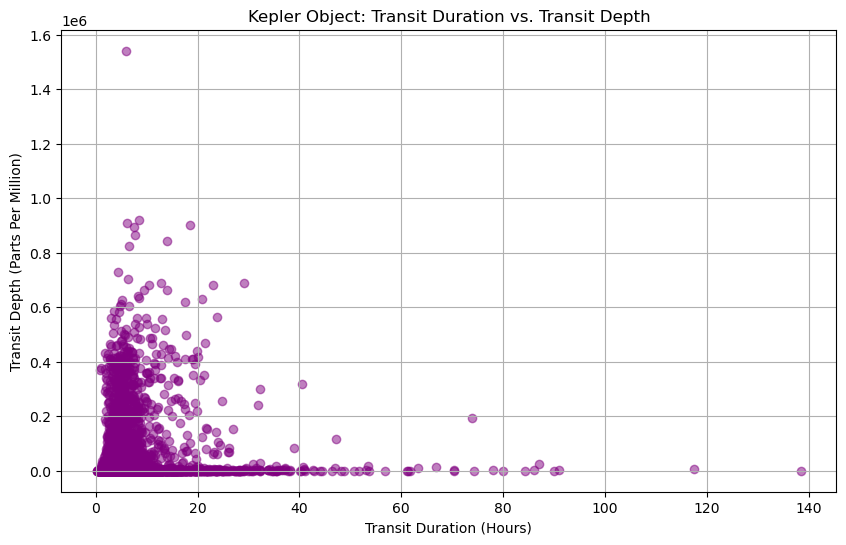

In [27]:



import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# time duration on x-axis, brightness dip (depth) on y-axis
plt.scatter(df['koi_duration'], df['koi_depth'], alpha=0.5, c='purple')

plt.title('Kepler Object: Transit Duration vs. Transit Depth')
plt.xlabel('Transit Duration (Hours)')
plt.ylabel('Transit Depth (Parts Per Million)')
plt.grid(True)
plt.show()

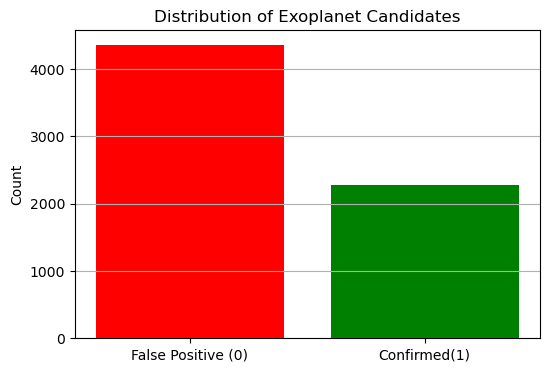

In [28]:
# count how many 1s and 0s are in koi_disposition 
counts = df['koi_disposition'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['False Positive (0)', 'Confirmed(1)'], counts, color=['red', 'green'])
plt.title('Distribution of Exoplanet Candidates')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

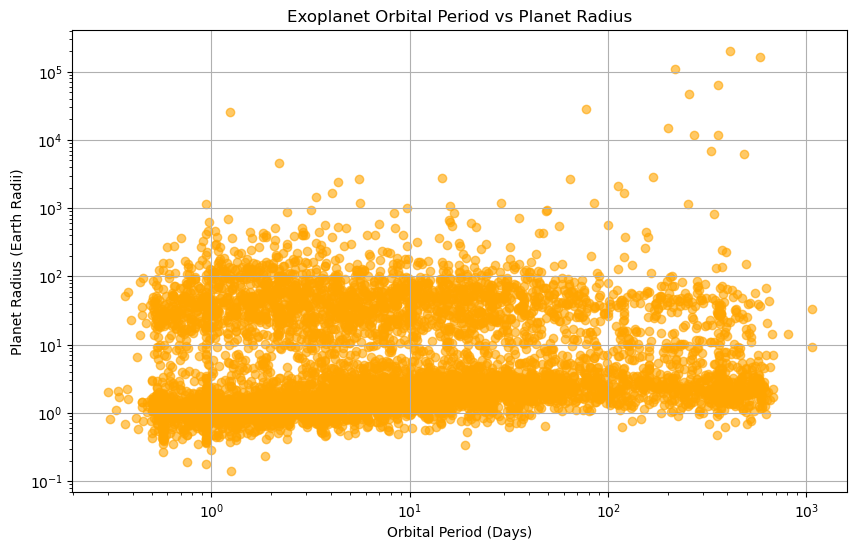

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(df['koi_period'], df['koi_prad'], alpha=0.6, c='orange')

# use log scale because orbital periods vary wildly 
plt.xscale('log')
plt.yscale('log')

plt.title('Exoplanet Orbital Period vs Planet Radius')
plt.xlabel('Orbital Period (Days)')
plt.ylabel('Planet Radius (Earth Radii)')
plt.grid(True)
plt.show()